In [1]:
# Task 1 : Date Feature Engineering

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load the data
df_promo = pd.read_csv('C:\\Users\\Vivek Vishwakarma\\Documents\\BA w AI\\0B_Assignments\\Assignment_4A&4B\\ml-assessment-bitsom_ba_2511306_Vishwakarma_Vivek\\data\\q3_retail_promotions.csv')

# Convert transaction_date to datetime objects
df_promo['transaction_date'] = pd.to_datetime(df_promo['transaction_date'])

# Extract date features
df_promo['year'] = df_promo['transaction_date'].dt.year
df_promo['month'] = df_promo['transaction_date'].dt.month
df_promo['day_of_week'] = df_promo['transaction_date'].dt.dayofweek # Monday=0, Sunday=6
df_promo['is_month_end'] = (df_promo['transaction_date'].dt.day >= 25).astype(int)

print("--- Data after Date Feature Engineering ---")
display(df_promo[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].sample(5))

# Task 2: Temporal Train-Test Split 
# 1. Sort the data strictly by date
df_promo = df_promo.sort_values('transaction_date').reset_index(drop=True)

# 2. Calculate the index for the 80% split mark
split_index = int(len(df_promo) * 0.8)

# 3. Split the data sequentially
train_df = df_promo.iloc[:split_index]
test_df = df_promo.iloc[split_index:]

print(f"\nTotal Records: {len(df_promo)}")
print(f"Training Set (Past 80%): {len(train_df)} records")
print(f"Test Set (Recent 20%): {len(test_df)} records")

--- Data after Date Feature Engineering ---


,transaction_date,year,month,day_of_week,is_month_end
1150,2024-11-17,2024,11,6,0
233,2022-07-17,2022,7,6,0
404,2023-01-26,2023,1,3,1
519,2023-05-21,2023,5,6,0
1192,2024-12-22,2024,12,6,0



Total Records: 1200
Training Set (Past 80%): 960 records
Test Set (Recent 20%): 240 records


### Why a Random Split is Inappropriate for Time-Ordered Data
As discussed in our lectures regarding demand forecasting, using a random `train_test_split` on time-series data causes "data leakage." A random split shuffles the rows, meaning the model would be trained on future data to predict past events. 

In real-world retail scenarios, our objective is to use historical data to predict *unseen future* sales. Therefore, we must preserve the strict chronological order of the dataset. By sorting the data by `transaction_date` and taking the most recent 20% as our test set, we accurately simulate reality: using the past (80%) to forecast the future (20%).

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Separate features (X) and target (y)
# We drop 'transaction_date' as models can't process datetimes, and we already extracted its features
X_train = train_df.drop(columns=['items_sold', 'transaction_date'])
y_train = train_df['items_sold']

X_test = test_df.drop(columns=['items_sold', 'transaction_date'])
y_test = test_df['items_sold']

# 2. Identify columns for transformation
cat_cols = ['promotion_type', 'location_type', 'store_size']
num_cols = [col for col in X_train.columns if col not in cat_cols]

# Task 3: Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ])

# Build the full pipelines for both models
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Task 4: Model Training and Evaluation
# Fit the pipelines ONLY on the training set
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Predict on test set
lr_preds = lr_pipeline.predict(X_test)
rf_preds = rf_pipeline.predict(X_test)

# Calculate and print metrics
print("--- Linear Regression Performance ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_preds)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, lr_preds):.2f}\n")

print("--- Random Forest Performance ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_preds)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, rf_preds):.2f}\n")

--- Linear Regression Performance ---
RMSE: 27.12
MAE: 21.05

--- Random Forest Performance ---
RMSE: 31.66
MAE: 24.90



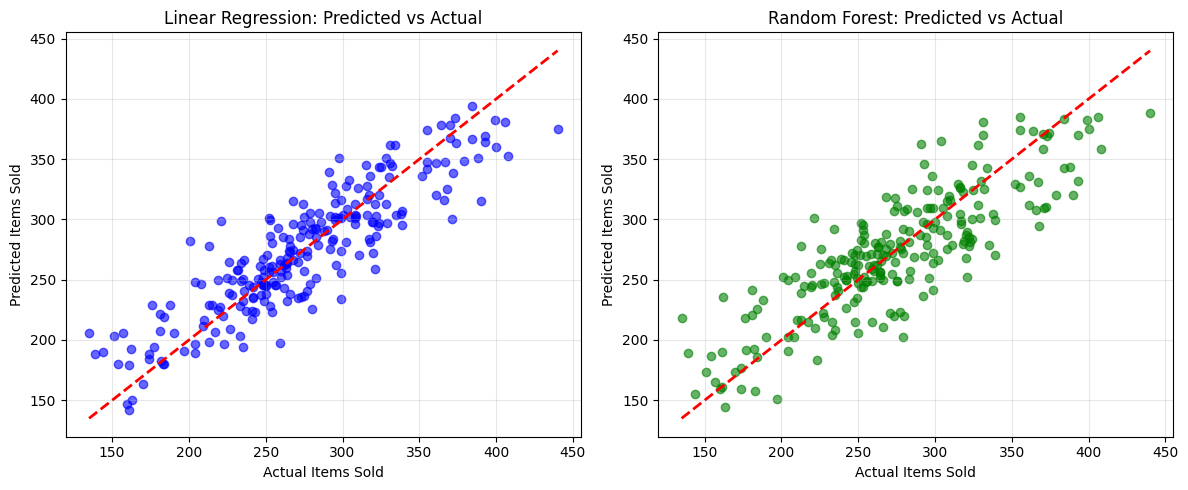

--- Top 5 Most Influential Features (Random Forest) ---


,Feature,Importance
0,store_size_small,0.183953
1,is_festival,0.174490
2,location_type_urban,0.140494
3,day_of_week,0.087179
4,is_weekend,0.066870


In [3]:
# 1. Produce Parity Plots
plt.figure(figsize=(12, 5))

# Linear Regression Parity Plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, lr_preds, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal reference line
plt.title('Linear Regression: Predicted vs Actual')
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.grid(True, alpha=0.3)

# Random Forest Parity Plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_preds, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal reference line
plt.title('Random Forest: Predicted vs Actual')
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Extract and Print Top 5 Feature Importances (From Random Forest)
# First, extract the actual feature names generated by the OneHotEncoder
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_feature_names)

# Grab the importances from the trained Random Forest step in the pipeline
importances = rf_pipeline.named_steps['regressor'].feature_importances_

# Create a dataframe and sort it
importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("--- Top 5 Most Influential Features (Random Forest) ---")
display(importance_df.head(5))